In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import transforms
from tqdm import tqdm

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problems.encoder_decoder import EncoderDecoderProblem
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.pullback.standard import StandardPullbackVectorRiemannianAutoencoder
from src.transforms.parity.tanh import TanhParityTransform
from src.transforms.householder_linear import HouseholderLinearTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

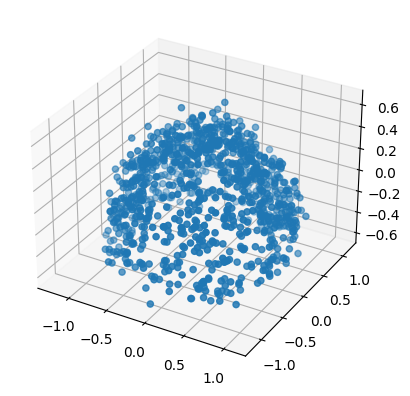

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_clean = uniform_sphere_sampling(3, num_samples)
data_clean_mean = data_clean.mean(0)
data_clean -= data_clean_mean
data_train_clean = data_clean
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x

In [4]:
def create_context_encoder(dim, hidden_dim):
    context_encoder = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2*dim)
        )
    return context_encoder

In [5]:
# Define the normalizing flow model
def create_flow_transform(dim, n_flows, n_hoho, order):
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(transforms.normalization.ActNorm(features=dim))
        for k in range(n_hoho):
            transforms_list.append(HouseholderLinearTransform(dim))
        transforms_list.append(TanhParityTransform(dim, order))
    flow_transform = transforms.CompositeTransform(transforms_list)
    return flow_transform

In [6]:
# Initialize the model
forward = IdentityForward()

dim = 3

# construct context encoder
hidden_dim = 32
context_encoder = create_context_encoder(dim, hidden_dim)

# construct flow transform
n_flows = 2
n_hoho = 2
order = 2
flow_transform = create_flow_transform(dim, n_flows, n_hoho, order)

model = EncoderDecoderProblem([dim], forward, context_encoder, flow_transform, noise_level).to(device)
# model = EncoderDecoderProblem([dim], forward, context_encoder, flow_transform, noise_level, low_rank_reg_param=0.1, clean_data_reg_param=1.).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
# optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.)

In [7]:
# Training loop
def train(model, train_loader, optimizer, n_epochs):
    for epoch in range(n_epochs):
        for y in tqdm(train_loader):
            optimizer.zero_grad()
            
            y = y.to(device)
            x = data_clean[0:100].to(device)
            # Compute loss
            loss = model.reconstruction_loss(y, x=x)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [8]:
# Train the model
n_epochs = 250
train(model, train_loader, optimizer, n_epochs)

100%|██████████| 8/8 [00:01<00:00,  7.90it/s]


Epoch 1/250, Loss: 33.1625


100%|██████████| 8/8 [00:00<00:00,  8.40it/s]


Epoch 2/250, Loss: 27.6795


100%|██████████| 8/8 [00:01<00:00,  7.66it/s]


...

Epoch 248/250, Loss: 6.2772


100%|██████████| 8/8 [00:00<00:00,  8.50it/s]


Epoch 249/250, Loss: 6.2518


100%|██████████| 8/8 [00:00<00:00,  8.49it/s]

Epoch 250/250, Loss: 6.2465


In [9]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [10]:
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

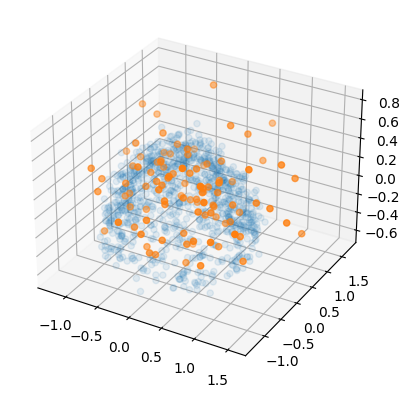

In [11]:
# Visualize generated samples
samples = generate_samples(model.p_pri, 100)

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
plt.show()

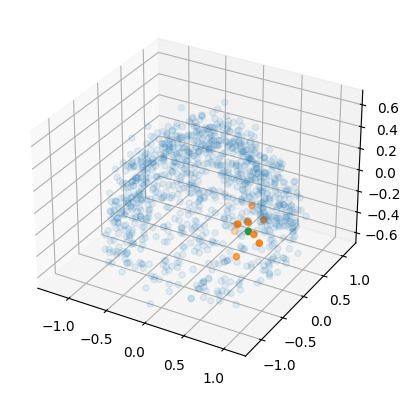

In [12]:
# Visualize generated samples
context = data_train[8]
samples = generate_samples_with_context(model.p_pos, 10, context.to(device))

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Evaluating Geometry ###

In [13]:
# Construct pullback manifold
phi = NFlowVectorDiffeomorphism(dim, model.p_pri)       
manifold = StandardPullbackVectorEuclidean(phi)

In [14]:
# special points
x0 = (torch.tensor([0.,0.,1.]) - data_clean_mean).to(device)
x1 = (torch.tensor([1.,0.,0.]) - data_clean_mean).to(device)

In [15]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

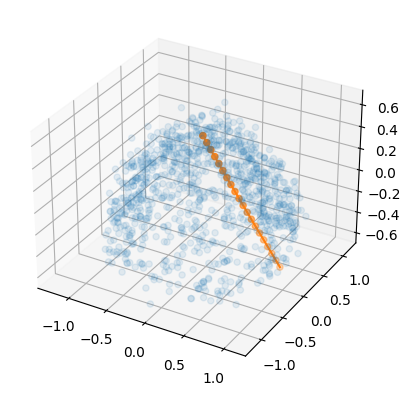

In [16]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

#### RAE construction ####

##### Tangent space PCA #####

In [17]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)

tensor([ 0.0002, -0.0234,  0.0103], grad_fn=<SelectBackward0>)


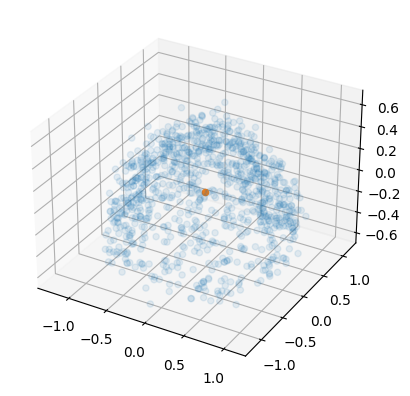

In [18]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [19]:
# construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCAVectorSolver(data_train.to(device), manifold, bary)

In [20]:
# compute low rank approximations
Xi, approximations, _ = l2_pga_solver.solve(2)

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


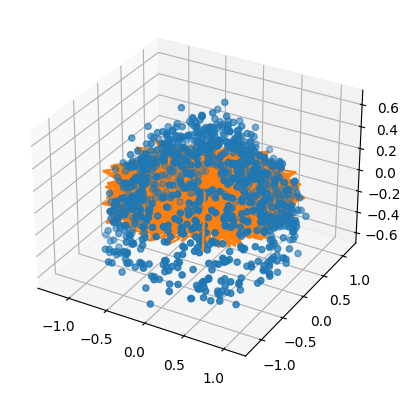

In [21]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             Xi.detach().cpu().numpy()[i, 0], Xi.detach().cpu().numpy()[i, 1], Xi.detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


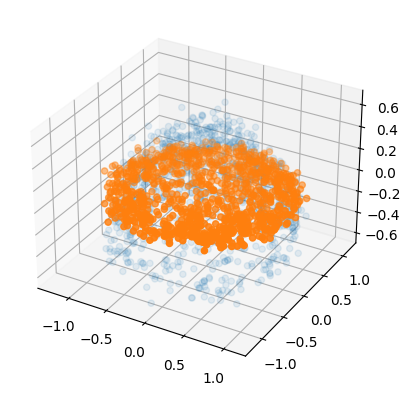

In [22]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [23]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(0.0897, grad_fn=<SumBackward0>)


##### Standard Normalizing Flow RAE #####

In [24]:
# Construct RAE
epsilon = 0.1
d_epsilon = 2
rae_ = StandardPullbackVectorRiemannianAutoencoder(manifold, epsilon=epsilon, device=device)
rae = StandardPullbackVectorRiemannianAutoencoder(manifold, d_epsilon=d_epsilon, device=device)

constructed a Riemannian autoencoder with d_eps = 3 and effectice eps = 0.0
constructed a Riemannian autoencoder with d_eps = 2 and effectice eps = 0.12550082802772522


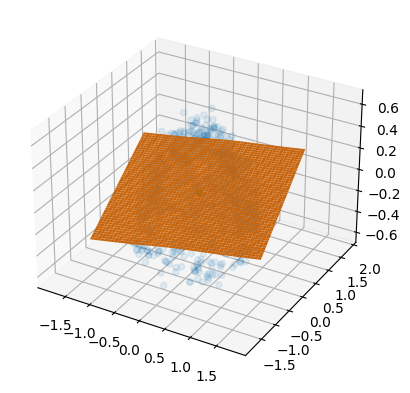

In [25]:
L = 50
x = torch.linspace(-1.5, 1.5, steps=L, device=device)
y = torch.linspace(-1.5, 1.5, steps=L, device=device)
grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    decoded = rae.decode(coordinates)  
    x_bar = manifold.phi.inverse(torch.zeros(1,3,device=x.device))[0].cpu()
X = decoded[:, 0].reshape(L, L).cpu()
Y = decoded[:, 1].reshape(L, L).cpu()
Z = decoded[:, 2].reshape(L, L).cpu()

# Create 3D plot
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(x_bar[0], x_bar[1], x_bar[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
ax.plot_surface(X, Y, Z, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [26]:
rae_approximations = rae.project_on_manifold(data_train.to(device)).detach().cpu().numpy()

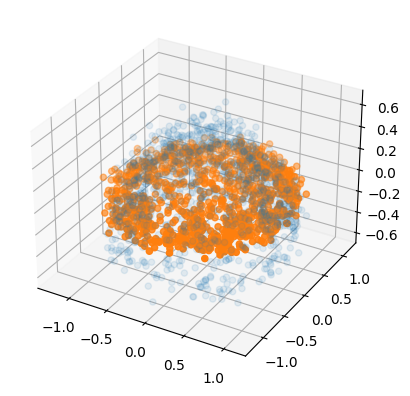

In [27]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rae_approximations[:,0], rae_approximations[:,1], rae_approximations[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [28]:
# compute approximation errors
print(torch.mean((data_train - rae_approximations)**2,0).sum())

tensor(0.0913)


##### Posterior Tangent Space PCA #####

In [29]:
# use all data to sample from the learned conditional (and take the mean per conditioning data point)
# do tangent space pca wrt to the prior diffeomorphism to get the subspace
rec_data_train = torch.zeros(data_train.shape[0], 3)
for i, context in enumerate(data_train):
    samples = generate_samples_with_context(model.p_pri, 10, context.to(device))
    rec_data_train[i] = samples.mean(0)

In [30]:
# compute barycentre
rec_bary = manifold.barycentre(rec_data_train.to(device))
print(rec_bary)

tensor([-0.0093, -0.0090,  0.0017], grad_fn=<SelectBackward0>)


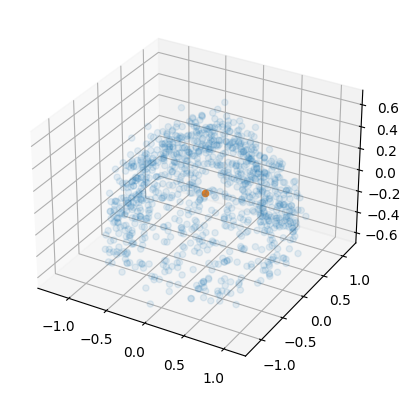

In [31]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [32]:
# construct l2-pga solver
rec_l2_pga_solver = l2TangentSpacePCAVectorSolver(rec_data_train.to(device), manifold, rec_bary)

In [33]:
# compute low rank approximations
rec_Xi, rec_approximations, _ = rec_l2_pga_solver.solve(2)

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


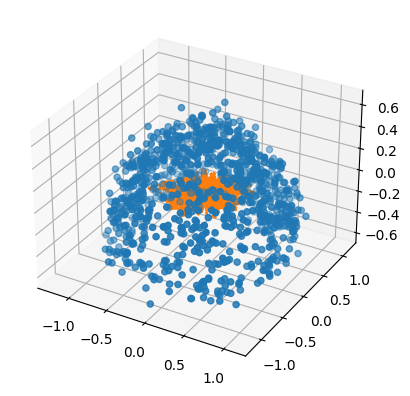

In [34]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(rec_l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], 
             rec_Xi.detach().cpu().numpy()[i, 0], rec_Xi.detach().cpu().numpy()[i, 1], rec_Xi.detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


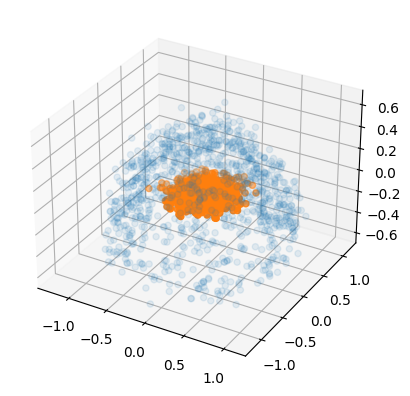

In [35]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_approximations.detach().cpu().numpy()[:,0], rec_approximations.detach().cpu().numpy()[:,1], rec_approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [36]:
print(torch.mean((data_train.to(device) - rec_approximations)**2,0).sum())
print(torch.mean((rec_data_train.to(device) - rec_approximations)**2,0).sum())

tensor(0.8751, grad_fn=<SumBackward0>)
tensor(0.0093, grad_fn=<SumBackward0>)


##### Posterior RAE #####

In [37]:
l2_tpca_rae = l2TangentSpacePCAPullbackVectorRiemannianAutoencoder(manifold, rec_data_train.to(device), 2)

constructed a Riemannian autoencoder with latent dimension = 2 and effectice eps = 0.20537741482257843


In [38]:
print(l2_pga_solver.base_point.shape)

torch.Size([3])


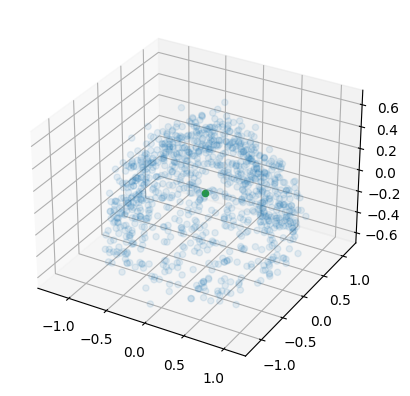

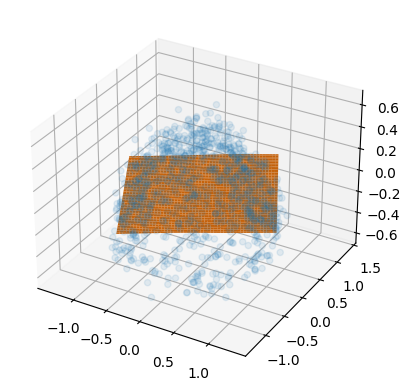

In [39]:
L = 50
x = torch.linspace(-1., 1., steps=L, device=device)
y = torch.linspace(-1., 1., steps=L, device=device)
grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    decoded = l2_tpca_rae.decode(coordinates)  
    x_bar = l2_tpca_rae.base_point.detach().cpu()
X = decoded[:, 0].reshape(L, L).cpu()
Y = decoded[:, 1].reshape(L, L).cpu()
Z = decoded[:, 2].reshape(L, L).cpu()

# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(x_bar[0], x_bar[1], x_bar[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()

# Create 3D plot
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot_surface(X, Y, Z, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [40]:
rec_l2_tpca_rae_approximations = l2_tpca_rae.project_on_manifold(rec_data_train.to(device)).detach().cpu().numpy()

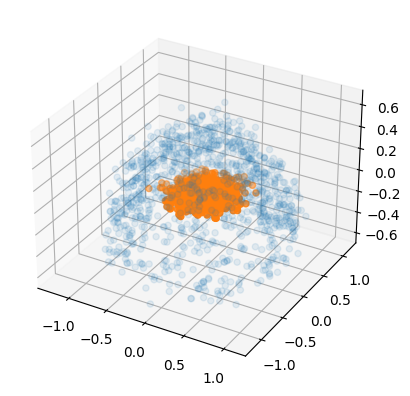

In [41]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_l2_tpca_rae_approximations[:,0], rec_l2_tpca_rae_approximations[:,1], rec_l2_tpca_rae_approximations[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [42]:
# compute approximation errors
print(torch.mean((rec_data_train - rec_l2_tpca_rae_approximations)**2,0).sum())

tensor(0.0093)
